In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plot style
sns.set(style="whitegrid")
plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


In [50]:
# 1. Load the full dataset to ensure 'InvoiceNo' is included
df_path = 'data/Online_Retail.xlsx'
df = pd.read_excel(df_path, dtype={'InvoiceNo': str, 'StockCode': str}) # Reading InvoiceNo as string
print(f"Successfully loaded original dataset with shape: {df.shape}")

# 2. Perform all cleaning steps
# Remove records with missing CustomerID [cite: 15]
df.dropna(subset=['CustomerID'], inplace=True)
# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Filter for United Kingdom only [cite: 16]
df_uk = df[df['Country'] == 'United Kingdom'].copy()

# Remove cancelled orders (InvoiceNo starts with 'C') [cite: 17]
df_uk = df_uk[~df_uk['InvoiceNo'].str.startswith('C', na=False)]

# Remove transactions with non-positive quantity or zero price
df_uk = df_uk[(df_uk['Quantity'] > 0) & (df_uk['UnitPrice'] > 0)]

# 3. Final preparation for RFM
# Convert InvoiceDate to datetime
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])
# Create TotalPrice column
df_uk['TotalPrice'] = df_uk['Quantity'] * df_uk['UnitPrice']


print(f"Final shape of the cleaned dataset: {df_uk.shape}")
print("\n--- Corrected DataFrame Info ---")
df_uk.info()
print("\n--- Corrected DataFrame Head ---")
display(df_uk.head())

Successfully loaded original dataset with shape: (541909, 8)
Final shape of the cleaned dataset: (354321, 9)

--- Corrected DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 354321 entries, 0 to 541893
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    354321 non-null  object        
 1   StockCode    354321 non-null  object        
 2   Description  354321 non-null  object        
 3   Quantity     354321 non-null  int64         
 4   InvoiceDate  354321 non-null  datetime64[ns]
 5   UnitPrice    354321 non-null  float64       
 6   CustomerID   354321 non-null  int64         
 7   Country      354321 non-null  object        
 8   TotalPrice   354321 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 27.0+ MB

--- Corrected DataFrame Head ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [51]:
# Set a snapshot date for recency calculation (one day after the last transaction in the dataset)
snapshot_date = df_uk['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date for Recency calculation: {snapshot_date}")

# Group by CustomerID and calculate RFM metrics
rfm = df_uk.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename the columns to be more descriptive
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)

print("\nRFM table created successfully!")
display(rfm.head())

# Check the distribution of the RFM values
print("\nDescription of the RFM table:")
display(rfm.describe())

Snapshot date for Recency calculation: 2011-12-10 12:49:00

RFM table created successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,209,33719.73
12749,4,5,4090.88
12820,3,4,942.34



Description of the RFM table:


,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.208418,4.246429,1864.385601
std,99.533854,7.199202,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,300.280000
50%,51.000000,2.000000,652.280000
75%,143.000000,5.000000,1576.585000
max,374.000000,209.000000,259657.300000


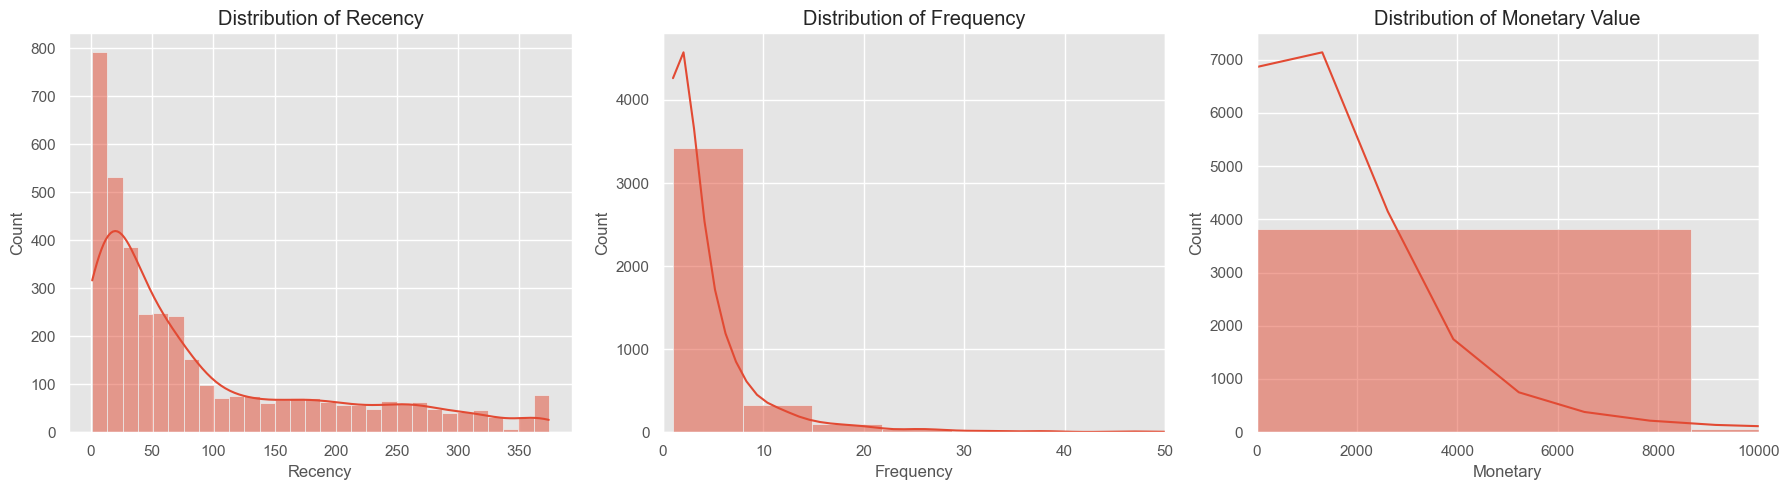

In [52]:
# Create histograms for each RFM feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Recency
sns.histplot(rfm['Recency'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Recency')

# Plot Frequency
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Distribution of Frequency')
axes[1].set_xlim(0, 50) # Limiting x-axis for better visibility due to outliers

# Plot Monetary
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], kde=True)
axes[2].set_title('Distribution of Monetary Value')
axes[2].set_xlim(0, 10000) # Limiting x-axis for better visibility due to outliers


plt.tight_layout()
plt.show()

In [53]:
from sklearn.preprocessing import StandardScaler

# 1. Log Transformation to handle skewness
# We use np.log1p which calculates log(1+x) to avoid issues with zero values if they existed.
# rfm_log = np.log1p(rfm)

# 2. Standardization
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the log-transformed data
rfm_scaled = scaler.fit_transform(rfm)

# Convert the scaled array back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("--- Head of the Scaled RFM Data ---")
display(rfm_scaled_df.head())

print("\n--- Description of the Scaled RFM Data ---")
display(rfm_scaled_df.describe())

--- Head of the Scaled RFM Data ---


,Recency,Frequency,Monetary
CustomerID,,,
12346,2.349165,-0.451000,10.066906
12747,-0.906425,0.938220,0.311637
12748,-0.916473,28.444775,4.257675
12749,-0.886328,0.104688,0.297586
12820,-0.896376,-0.034234,-0.123237



--- Description of the Scaled RFM Data ---


,Recency,Frequency,Monetary
count,3.920000e+03,3.920000e+03,3.920000e+03
mean,-4.984675e-18,5.981610e-17,3.443957e-17
std,1.000128e+00,1.000128e+00,1.000128e+00
min,-9.164726e-01,-4.510003e-01,-2.486861e-01
25%,-7.456547e-01,-4.510003e-01,-2.090530e-01
50%,-4.140669e-01,-3.120783e-01,-1.620059e-01
75%,5.103596e-01,1.046876e-01,-3.846644e-02
max,2.831474e+00,2.844478e+01,3.445571e+01


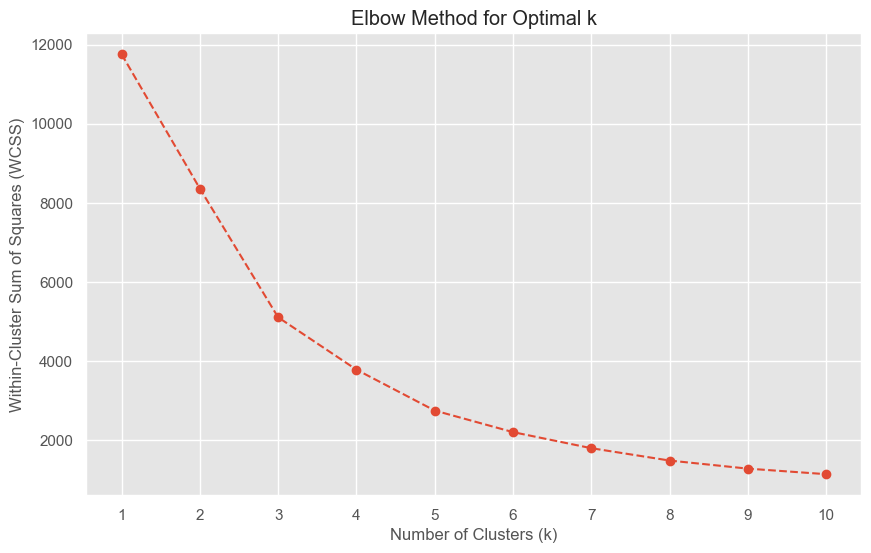

In [54]:
from sklearn.cluster import KMeans

# Calculate WCSS for a range of number of clusters
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.show()

In [55]:
# Set the optimal number of clusters
optimal_k = 3

# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

# Add the cluster labels to the original RFM dataframe (not the scaled one)
rfm_with_clusters = rfm.copy()
rfm_with_clusters['Cluster'] = cluster_labels

# Calculate the average RFM values for each cluster
cluster_summary = rfm_with_clusters.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(f"--- K-Means Clustering Results (k={optimal_k}) ---")
display(cluster_summary)

--- K-Means Clustering Results (k=3) ---


,Recency,Frequency,Monetary
Cluster,,,
0,40.75,4.72,1785.03
1,243.78,1.59,487.60
2,19.39,59.91,71494.41


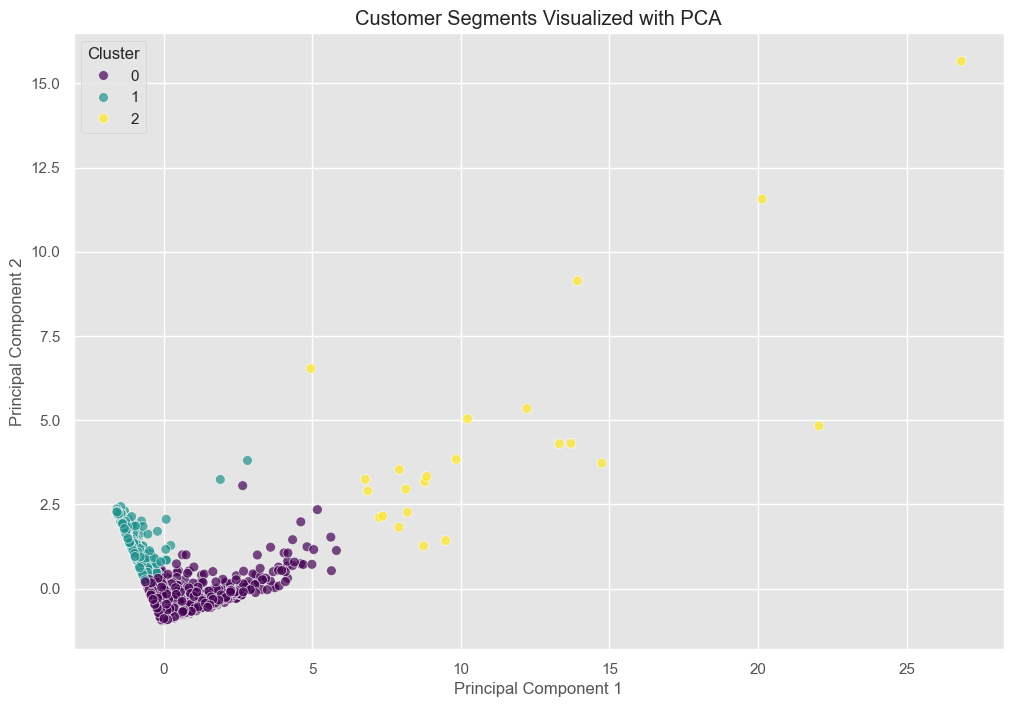

In [56]:
from sklearn.decomposition import PCA

# --- Perform PCA ---
# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)

# Fit and transform the scaled data
rfm_pca = pca.fit_transform(rfm_scaled_df)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels # Add the cluster labels

# --- Plot the PCA results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=50, alpha=0.7)

plt.title('Customer Segments Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

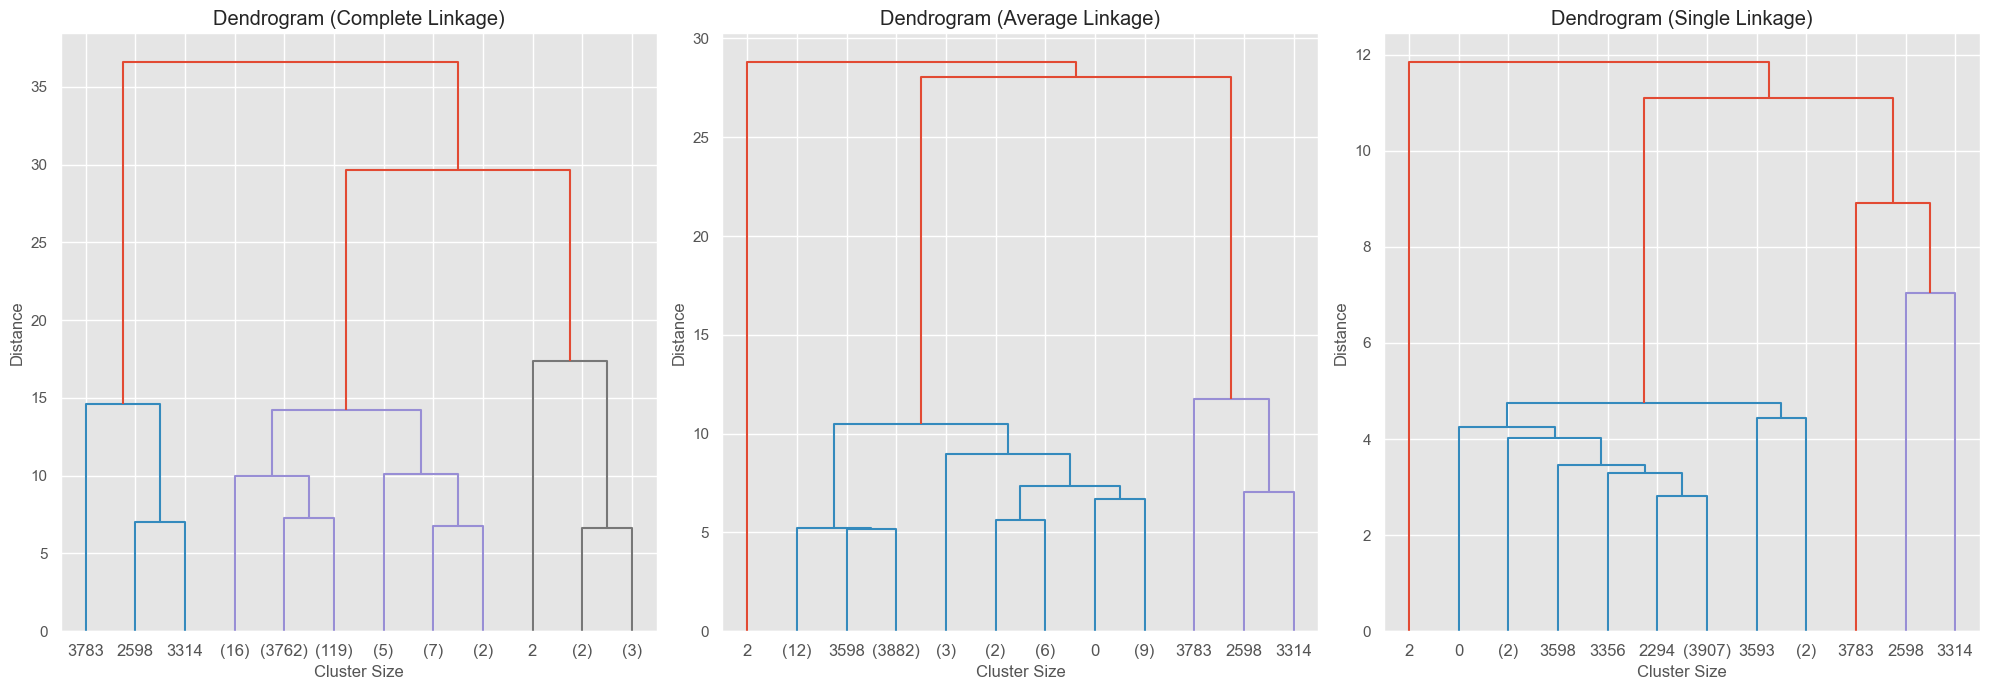

In [57]:
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Create a figure for the three dendrograms ---
plt.figure(figsize=(20, 7))

# --- 1. Complete Linkage ---
plt.subplot(1, 3, 1)
plt.title('Dendrogram (Complete Linkage)')
# The linkage function calculates the distances and merges
linked_complete = linkage(rfm_scaled_df, method='complete')
# The dendrogram function plots the hierarchy
dendrogram(linked_complete,
           truncate_mode='lastp', # Show only the last p merged clusters
           p=12,                # The 'p' parameter
           show_leaf_counts=True)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")

# --- 2. Average Linkage ---
plt.subplot(1, 3, 2)
plt.title('Dendrogram (Average Linkage)')
linked_average = linkage(rfm_scaled_df, method='average')
dendrogram(linked_average,
           truncate_mode='lastp',
           p=12,
           show_leaf_counts=True)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")

# --- 3. Single Linkage ---
plt.subplot(1, 3, 3)
plt.title('Dendrogram (Single Linkage)')
linked_single = linkage(rfm_scaled_df, method='single')
dendrogram(linked_single,
           truncate_mode='lastp',
           p=12,
           show_leaf_counts=True)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [58]:
from sklearn.cluster import AgglomerativeClustering

# Initialize and fit the Agglomerative Clustering model
# We choose 4 clusters based on the complete linkage dendrogram
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='complete')
hierarchical_labels = agg_cluster.fit_predict(rfm_scaled_df)

# Add the hierarchical cluster labels to the RFM dataframe
rfm_with_hierarchical = rfm.copy()
rfm_with_hierarchical['Hierarchical_Cluster'] = hierarchical_labels

# Calculate the average RFM values for each cluster
hierarchical_summary = rfm_with_hierarchical.groupby('Hierarchical_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("--- Hierarchical Clustering Results (Complete Linkage, k=4) ---")
display(hierarchical_summary)

--- Hierarchical Clustering Results (Complete Linkage, k=4) ---


,Recency,Frequency,Monetary
Hierarchical_Cluster,,,
0,3.33,36.00,207560.20
1,2.20,98.20,36786.37
2,92.41,4.05,1653.81
3,1.00,209.00,33719.73


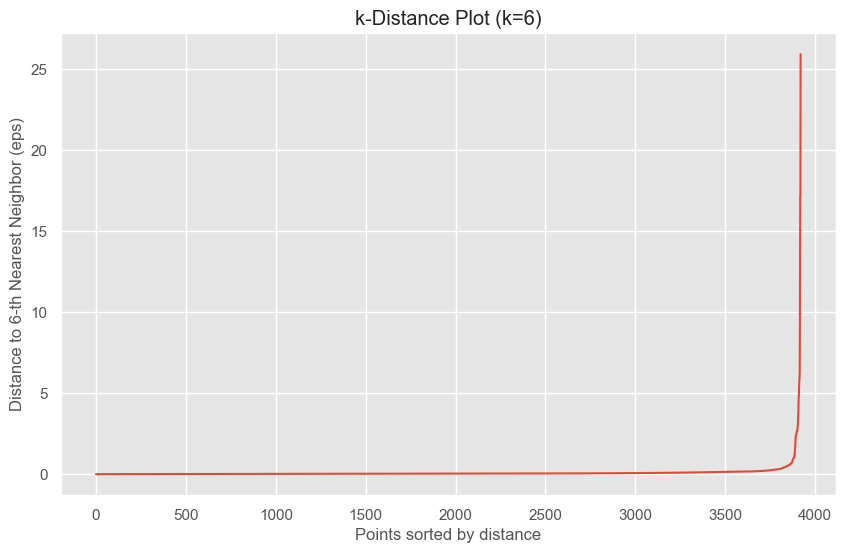

In [59]:
from sklearn.neighbors import NearestNeighbors

# We use min_samples = 6, which is 2 * number of features
min_samples = 6
k = min_samples

# Calculate the distance to the k-th nearest neighbor for each point
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(rfm_scaled_df)
distances, indices = neighbors_fit.kneighbors(rfm_scaled_df)

# Sort the distances and plot
sorted_distances = np.sort(distances[:, k-1])
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title(f'k-Distance Plot (k={k})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k}-th Nearest Neighbor (eps)')
plt.grid(True)
plt.show()

In [60]:
from sklearn.cluster import DBSCAN

# Set parameters based on the k-distance plot
eps = 0.6
min_samples = 4

# Initialize and fit the DBSCAN model
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(rfm_scaled_df)

# --- Analyze the results ---
# Get the number of clusters (excluding noise, which is labeled -1)
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_} cluster(s).")
print(f"It identified {n_noise_} noise points.")

# Add the DBSCAN cluster labels to the RFM dataframe
rfm_with_dbscan = rfm.copy()
rfm_with_dbscan['DBSCAN_Cluster'] = dbscan_labels

# Calculate the average RFM values for each cluster (filtering out noise)
dbscan_summary = rfm_with_dbscan[rfm_with_dbscan['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("\n--- DBSCAN Clustering Results ---")
display(dbscan_summary)

DBSCAN found 1 cluster(s).
It identified 39 noise points.

--- DBSCAN Clustering Results ---


,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
0,92.78,3.83,1345.27


In [61]:
from sklearn.metrics import silhouette_score

# --- Calculate Silhouette Scores ---

# 1. K-Means
kmeans_silhouette = silhouette_score(rfm_scaled_df, cluster_labels)

# 2. Hierarchical Clustering
hierarchical_silhouette = silhouette_score(rfm_scaled_df, hierarchical_labels)

# 3. DBSCAN
# Note: Silhouette score is only defined if there is more than 1 cluster.
# We also typically calculate it on the non-noise points.
dbscan_core_samples_mask = dbscan_labels != -1
#dbscan_silhouette = silhouette_score(rfm_scaled_df[dbscan_core_samples_mask], dbscan_labels[dbscan_core_samples_mask])


# --- Print the results ---
print("--- Clustering Evaluation: Silhouette Scores ---")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette:.4f}")
#print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")

--- Clustering Evaluation: Silhouette Scores ---
K-Means Silhouette Score: 0.5806
Hierarchical Clustering Silhouette Score: 0.8932
